Loading test dataset...
Evaluating on: CPU

Loading BART...


Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Generating summaries with BART...


  0%|          | 0/100 [00:00<?, ?it/s]

...

Generating summaries with PEGASUS...


  0%|          | 0/100 [00:00<?, ?it/s]

Calculating ROUGE for PEGASUS...

Results saved to results/model_comparison_results.csv


,Model,ROUGE-1,ROUGE-2,ROUGE-L
0,BART,0.428530,0.243251,0.389959
1,T5,0.410422,0.236910,0.380913
2,PEGASUS,0.421179,0.247532,0.385002


Chart saved to ../results/model_comparison_chart.png


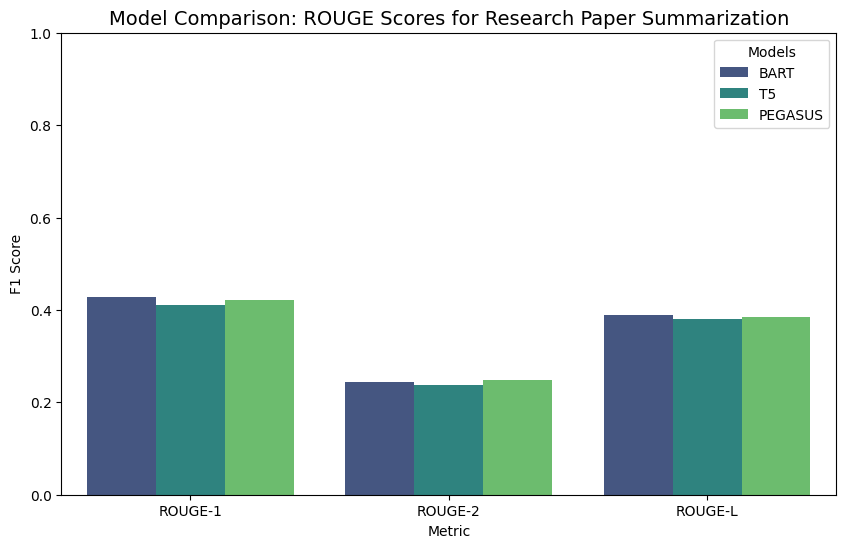

In [7]:
import pandas as pd
import torch
import os
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from evaluate import load
from tqdm.notebook import tqdm

# Load the ROUGE metric
rouge = load('rouge')

# Load a small sample of UNSEEN data for testing (e.g., skip the first 75k used for training)
data_path = "../data/processed/arxiv_sample.csv"
print("Loading test dataset...")
test_df = pd.read_csv(data_path, skiprows=range(1, 75001), nrows=100)
test_df = test_df.dropna(subset=['abstract', 'title'])
abstracts = test_df['abstract'].tolist()
real_titles = test_df['title'].tolist()

# Define the paths to your downloaded local models
model_paths = {
    "BART": "../models/Model_BART",
    "T5": "../models/Model_T5",
    "PEGASUS": "../models/Model_Pegasus"
}

results = []
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Evaluating on: {device.upper()}")

# Evaluate each model
for model_name, path in model_paths.items():
    if not os.path.exists(path):
        print(f"⚠️ Skipping {model_name}: Folder not found at {path}")
        continue
        
    print(f"\nLoading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(path)
    model = AutoModelForSeq2SeqLM.from_pretrained(path).to(device)
    
    generated_titles = []
    
    print(f"Generating summaries with {model_name}...")
    for text in tqdm(abstracts):
        # T5 requires the special prefix
        if model_name == "T5":
            text = "summarize: " + text
            
        inputs = tokenizer(text, max_length=128, truncation=True, return_tensors="pt").to(device)
        summary_ids = model.generate(inputs["input_ids"], max_length=32, min_length=5, num_beams=4)
        title = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
        generated_titles.append(title)
        
    # Calculate ROUGE scores
    print(f"Calculating ROUGE for {model_name}...")
    score = rouge.compute(predictions=generated_titles, references=real_titles)
    
    results.append({
        "Model": model_name,
        "ROUGE-1": score['rouge1'],
        "ROUGE-2": score['rouge2'],
        "ROUGE-L": score['rougeL']
    })
    
    # Free up memory before loading the next model
    del model
    del tokenizer
    torch.cuda.empty_cache()

# --- Save and Visualize Results ---
if results:
    # Save to CSV
    os.makedirs("../results", exist_ok=True)
    results_df = pd.DataFrame(results)
    results_df.to_csv("../results/model_comparison_results.csv", index=False)
    print("\nResults saved to results/model_comparison_results.csv")
    display(results_df)
    
    # Plotting the Comparison Chart
    plt.figure(figsize=(10, 6))
    melted_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
    sns.barplot(x="Metric", y="Score", hue="Model", data=melted_df, palette="viridis")
    
    plt.title("Model Comparison: ROUGE Scores for Research Paper Summarization", fontsize=14)
    plt.ylabel("F1 Score")
    plt.ylim(0, 1.0)
    plt.legend(title="Models")
    
    chart_path = "../results/model_comparison_chart.png"
    plt.savefig(chart_path)
    print(f"Chart saved to {chart_path}")
    plt.show()
else:
    print("No models were evaluated. Make sure your model folders are in the correct place!")